<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [64]:
import pandas as pd
import psycopg2

import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

# для построения графиков
import matplotlib.pyplot as plt
import seaborn as sns

# Конечно, с игнорированием предупреждений нужно быть осторожным,
# но при вызове запросов указанными в модуле методами возникают предупреждения
import warnings
warnings.filterwarnings('ignore') 

In [65]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 
DBNAME = 'project_sql'
USER = 'skillfactory'
PASSWORD = 'cCkxxLVrDE8EbvjueeMedPKt'
HOST = '84.201.134.129'
PORT = 5432

In [66]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [7]:
# текст запроса
query_3_1 = f'''
    Select count(id) as vac_count
    From vacancies    
'''

In [8]:
# результат запроса
df = pd.read_sql_query(query_3_1, connection)
display(df)

,vac_count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [9]:
# текст запроса
query_3_2 = f'''
    Select count(id) as empl_count
    From employers    
'''

In [10]:
# результат запроса
df = pd.read_sql_query(query_3_2, connection)
display(df)

,empl_count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [11]:
# текст запроса
query_3_3 = f'''
    Select count(id) as area_count
    From areas    
'''

In [12]:
# результат запроса
df = pd.read_sql_query(query_3_3, connection)
display(df)

,area_count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [13]:
# текст запроса
query_3_3 = f'''
    Select count(id) as industr_count
    From industries    
'''

In [14]:
# результат запроса
df = pd.read_sql_query(query_3_3, connection)
display(df)

,industr_count
0,294


***

In [ ]:
# выводы по предварительному анализу данных

Количество вакансий примерно сопоставимо с количеством работодателей (в среднем около 2-3 вакансий на одного работодателя). Это говорит, что большого спроса на рынке вакансий нет. Появление новых вакансий носит, если можно так выразиться, "*штучный*" характер. Возможно, это связано с замедлением развития экономики с соответствующим замедлением появления новых компаний. При большой доле новых компаний количество вакансий приходящихся в среднем на одну компаниюю должно быть больше. По регионам аналогично, грубо говоря, 20 000 компаний на 1 000 регионов уж точно не говорит о бурном экономическом росте. Аналогично с отраслями 20 000 компаний на 300 отраслей тоже говорит о том, что на рынке труда предложений немного и условия задают работодатели. 50 000 вакансий это немного для населения России.
Говорить о том что, данные hh.ru могут не сооветствовать реальной ситуации на рынке труда, в наше время интернета, мне кажется, уже неуместно.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [19]:
# текст запроса
query_4_1 = f'''
    Select a.name,count(v.id) as cnt -- count по id надежней (априори нет незаполненных значений)
    From areas as a
        Join vacancies as v On v.area_id = a.id --соединяем таблицы вакансий с таблицей регионов
    Group by a.name -- Группируем по имени региона
    Order by count(v.id) Desc -- Сортировка по количеству вакансий по убыванию
'''

In [20]:
# результат запроса
df = pd.read_sql_query(query_4_1, connection)
display(df)

,name,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
...,...,...
764,Тарко-Сале,1
765,Новоаннинский,1
766,Бирск,1
767,Сасово,1


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [21]:
# текст запроса
query_4_2 = f'''
    Select count(id) as count_fork
    From vacancies
    Where salary_from is not null or salary_to is not null
'''

In [22]:
# результат запроса
df = pd.read_sql_query(query_4_2, connection)
display(df)

,count_fork
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [23]:
# текст запроса
query_4_3 = f'''

    /* Решил сделать вывод через объедение двух запросов*/
    /* Среднее значение определяется обычным делением суммы значений на количество значений */
    
    (
        Select ROUND( SUM( ROUND(salary_from) ) / COUNT(salary_from) ) as "Значение зарплаты, руб", 'Нижняя граница' as "Описание"
        From vacancies
        Where salary_from Is Not Null or salary_to Is Not Null
    )
    UNION ALL
    (
        Select ROUND( SUM( ROUND(salary_to) ) / COUNT(salary_to) ), 'Верхняя граница'
        From vacancies
        Where salary_from Is Not Null or salary_to Is Not Null
    )
    
'''

In [24]:
# результат запроса
df = pd.read_sql_query(query_4_3, connection)
display(df)

,"Значение зарплаты, руб",Описание
0,71065.0,Нижняя граница
1,110537.0,Верхняя граница


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [25]:
# текст запроса
query_4_4 = f'''

    -- Использую соединение строк через ||
    -- Группировка сначала по рабочему графику затем по типу трудоустройства
    -- В резельтате будут пары schedule — employment 
        
    Select schedule||' — '||employment as sched_empl, COUNT(id) as count_sched_empl
    From vacancies
    Group by schedule,employment
    Order by COUNT(id) Desc
'''

In [26]:
# результат запроса
df = pd.read_sql_query(query_4_4, connection)
display(df)

,sched_empl,count_sched_empl
0,Полный день — Полная занятость,35367
1,Удаленная работа — Полная занятость,7802
2,Гибкий график — Полная занятость,1593
3,Удаленная работа — Частичная занятость,1312
4,Сменный график — Полная занятость,940
5,Полный день — Стажировка,569
6,Вахтовый метод — Полная занятость,367
7,Полный день — Частичная занятость,347
8,Гибкий график — Частичная занятость,312
9,Полный день — Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [27]:
# текст запроса
query_4_5 = f'''
    Select experience, COUNT(id)
    From vacancies    
    Group by experience
    Order by COUNT(id)
'''

In [28]:
# результат запроса
df = pd.read_sql_query(query_4_5, connection)
display(df)

,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

In [ ]:
# выводы по детальному анализу вакансий

Распределение вакансий по регионам, в целом, пропорционально населению этих регионов. Но я в конце проекта сделаю для городов милионников, таблицу с отношением количества вакансий к населению городов, тогда возможно, Москва уже не будет на первом месте. По опыту работы отмечу,что достаточно большая часть работодателей могут взять на вакансию "Без опыта", скорей всего это работа не требующая большой подготовки. Почти всем требуются сотрудники с полной занятостью, и совсем немногие готовы взять на стажировку. Большая часть работодателей готова взять на удалённую работу, тут опять же играет роль современная доступность интернета и, как показало время Covid, понимание работодателями того, что удалённая работа может быть такой же эффективной, как и работа в офисе. 

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [29]:
# текст запроса
query_5_1 = f'''

    -- несколько топорно, но сделал два одинаковых запроса через Union
    -- Отсортировал по убыванию количества вакансий
    -- и с помощью Offset, Limit вывел нужные места ))

    (
        Select e.name, COUNT(v.id)
            From vacancies as v
                Join employers as e On v.employer_id = e.id -- соединение таблицы вакансий с таблицей работодателей             
        Group by e.id
        Order by COUNT(v.id) Desc
        Limit 1
    ) 
    UNION ALL
    (
        Select e.name, COUNT(v.id)
            From vacancies as v
                Join employers as e On v.employer_id = e.id                
        Group by e.id
        Order by COUNT(v.id) Desc
        Offset 4
        Limit 1
    )  
'''

In [30]:
# результат запроса
df = pd.read_sql_query(query_5_1, connection)
display(df)

,name,count
0,Яндекс,1933
1,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [31]:
# текст запроса
query_5_2 = f'''

/*
    для сохранения регионов, в которых нет вакансий использовал Left Join
    сделал отдельные запросы с выводом регионов и количества работодателей (группировка по регионам)
    и выводом регионов и количества вакансий (группировка по регионам)
    затем уже результаты этих двух запросов соединил между собой
    конечная сортировка по условию задания
    конечно, всегда смотрю контрольные точки
    количество строк должно совпадать с  количеством регинов задание 3_3
*/

With a_e as
(
    Select a.id as id, a.name as name,  COUNT(e.id) as empl_count
        From areas as a
        Left Join employers as e On a.id = e.area      
    Group by a.id   
),
a_v as
(
    Select a.id as id, COUNT(v.id) as vac_count
        From areas as a
        Left Join vacancies as v On a.id = v.area_id      
    Group by a.id
)

Select ae.name, ae.empl_count, av.vac_count
    From a_e as ae
        Left Join a_v as av On ae.id = av.id
Order by av.vac_count, ae.empl_count Desc     
'''

In [32]:
# результат запроса
df = pd.read_sql_query(query_5_2, connection)
display(df)

,name,empl_count,vac_count
0,Россия,410,0
1,Казахстан,207,0
2,Московская область,75,0
3,Краснодарский край,19,0
4,Ростовская область,18,0
...,...,...,...
1357,Алматы,721,1892
1358,Новосибирск,573,2006
1359,Минск,1115,2112
1360,Санкт-Петербург,2217,2851


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [33]:
# текст запроса
query_5_3 = f'''

    -- Соединение слева двух таблиц работодателей и вакансий, при этом подсчёт количества по area_id
    -- Использовал DISTINCT, так как у работодателя может быть несколько вавкансий в одном регионе
    -- количестов строк должно совпадать с заданием 3_2
    
    Select e.name, COUNT( DISTINCT v.area_id )
        From employers as e
            Left Join vacancies as v On e.id = v.employer_id
    Group by e.id
    Order by count(v.area_id) Desc
'''

In [34]:
# результат запроса
df = pd.read_sql_query(query_5_3, connection)
display(df)

,name,count
0,Яндекс,181
1,Ростелеком,152
2,Тинькофф,43
3,СБЕР,24
4,Газпром нефть,24
...,...,...
23496,МАКМАХ,0
23497,Завод Стелкон,0
23498,ИнтерЭВМ,0
23499,Фёдоров Михаил,0


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [35]:
# текст запроса
query_5_4 = f'''

    -- соединил слева таблицу работодателей с таблицей пар ключей
    -- и вывел работодалей, которых нет в этой таблице
    
    Select Count(e.id)
        From employers as e
            Left Join employers_industries as ei On e.id = ei.employer_id
    Where  ei.employer_id is Null    
'''

In [36]:
# результат запроса
df = pd.read_sql_query(query_5_4, connection)
display(df)

,count
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [37]:
# текст запроса
query_5_5 = f'''
    Select e.name, Count(ei.industry_id)
        From employers as e
            Join employers_industries as ei On e.id = ei.employer_id
    Group by e.id
    Having Count(ei.industry_id) = 4
    Order by e.name
    Offset 2
    Limit 1
''' 

In [38]:
# результат запроса
df = pd.read_sql_query(query_5_5, connection)
display(df)

,name,count
0,2ГИС,4


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [39]:
# текст запроса
query_5_6 = f'''
    Select Count(e.id)
        From employers as e
            Join employers_industries as ei On e.id = ei.employer_id
                Join industries as i On ei.industry_id = i.id And i.name = 'Разработка программного обеспечения'
''' 

In [40]:
# результат запроса
df = pd.read_sql_query(query_5_6, connection)
display(df)

,count
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [41]:
# код для получения списка городов-милионников
# сделал после изучения кода страницы в wikipedia
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России' # Определяем адрес страницы
headers={'User-Agent': 'Mozilla/5.0'} # Для соответствия политики wikipedia
response = requests.get(url, headers=headers) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
cities_list = []
# Цикл по тегам tr в таблице
for i , tr in enumerate(page.findAll('tbody')[0]): # Таблица со списком городов-миллионников это первая таблица
    if i == 0:
        continue # Первый title в таблице не имеет отношения к названиям городов-миллионников
    # Извлекаем из тега a аттрибут title и доабвляем к списку, с учетом
    # формирования будущих запросов
    cities_list.append("'" + tr.a.text + "'")
cities = ','.join(cities_list)

In [42]:
# текст запроса
query_5_7 = f'''

    /*

        Все запросы написаны с использованием f-строки, поэтому можно вставить в запрос
        полученный ранее список горожов-милионников cities
        объединяем два запроса один сггруппированный по имени регина
        второй общее количество поэтому без группировки
        соединяем три таблицы: работодатели, вакансии и регионы
        
    */
    
    (
        Select a.name as name, COUNT(v.id) as cnt
            From employers as e
                Join vacancies as v On e.id = v.employer_id
                    Join areas as a On v.area_id = a.id 
        Where e.name = 'Яндекс' and a.name in ({cities})
        Group by a.name
    )
    UNION ALL
    (
        Select 'Total', COUNT(v.id)
            From employers as e
                Join vacancies as v On e.id = v.employer_id
                    Join areas as a On v.area_id = a.id 
        Where e.name = 'Яндекс' and a.name in ({cities})
    )
    Order by cnt
''' 

In [43]:
# результат запроса
df = pd.read_sql_query(query_5_7, connection)
display(df)

,name,cnt
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Казань,25
6,Ростов-на-Дону,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

In [ ]:
# выводы по анализу работодателей

Конечно, обращает на себя внимание большое количество вакансий в Яндекс. Это говорит о значительном развитии компании. Теперь про вакансии в регионах. Ряд компаний (например, СБЕР) размещают вакансии  в регионах, так как имеют филиалы в регионах и им нужны люди из конкрентых регионов для работы в конретных филиалах. Другие компании (например, Яндекс), возможно, просто ищут в регионах новые кадры и так как эти люди будут скорей всего работать удалённо, то неважно из какого региона они будут. Если говорить про количество работодателей, у которых в качестве сферы деятельности указана *Разработка программного обеспечения*, то оно относительно небольшое. Лучше, возможно, увидеть сколько вакансий у каждой из этих 3500 компаний. Такую таблицу я подготовлю в конце проекта.

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [44]:
# текст запроса
query_6_1 = f'''
    Select Count(id)
        From vacancies
    Where 
        lower(name) Like '%data%'
        Or
        lower(name) Like '%данн%'
''' 

In [45]:
# результат запроса
df = pd.read_sql_query(query_6_1, connection)
display(df)

,count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [46]:
# текст запроса
query_6_2 = f'''
    Select Count(id)
        From vacancies
    Where 
            (
                    lower(name) Like '%data scientist%'
                Or
                    lower(name) Like '%data science%'
                Or
                    lower(name) Like '%исследователь данных%'
                Or
                    lower(name) Like '%machine learning%'
                Or
                    lower(name) Like '%машинн%обучен%'
                Or
                    (
                            name Like '%ML%'
                        And
                            name Not Like '%HTML%'            
                    )    
            )

        And
            (
                    lower(name) Like '%junior%'
                Or
                    lower(experience) Like '%нет опыта%'
                Or
                    lower(employment) Like '%cтажировка%'
            )
'''

In [47]:
# результат запроса
df = pd.read_sql_query(query_6_2, connection)
display(df)

,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [48]:
# текст запроса
query_6_3 = f'''
    Select Count(id)
        From vacancies
    Where 
            (
                    lower(name) Like '%data scientist%'
                Or
                    lower(name) Like '%data science%'
                Or
                    lower(name) Like '%исследователь данных%'
                Or
                    lower(name) Like '%machine learning%'
                Or
                    lower(name) Like '%машинн%обучен%'
                Or
                    (
                            name Like '%ML%'
                        And
                            name Not Like '%HTML%'            
                    )    
            )

    /*    And Not
            (
                    lower(name) Like '%junior%'
                Or
                    lower(experience) Like '%нет опыта%'
                Or
                    lower(employment) Like '%cтажировка%'
            )   */
        And
            (
                    lower(key_skills) like '%sql%'
                Or
                    lower(key_skills) like '%postgres%'
            )
'''

In [49]:
# результат запроса
df = pd.read_sql_query(query_6_3, connection)
display(df)

,count
0,201


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [50]:
# текст запроса
query_6_4 = f'''
    Select Count(id)
        From vacancies
    Where 
            (
                    lower(name) Like '%data scientist%'
                Or
                    lower(name) Like '%data science%'
                Or
                    lower(name) Like '%исследователь данных%'
                Or
                    lower(name) Like '%machine learning%'
                Or
                    lower(name) Like '%машинн%обучен%'
                Or
                    (
                            name Like '%ML%'
                        And
                            name Not Like '%HTML%'            
                    )    
            )

        And

            (
                    lower(key_skills) like '%python%'
            )
'''

In [51]:
# результат запроса
df = pd.read_sql_query(query_6_4, connection)
display(df)

,count
0,351


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [52]:
# текст запроса
query_6_5 = f'''

    SELECT ROUND(  SUM( array_length ( string_to_array(key_skills, '\t') , 1) ) / ( 1.0 * Count(key_skills) ) , 2) 
        From vacancies
     Where 
            (
                    lower(name) Like '%data scientist%'
                Or
                    lower(name) Like '%data science%'
                Or
                    lower(name) Like '%исследователь данных%'
                Or
                    lower(name) Like '%machine learning%'
                Or
                    lower(name) Like '%машинн%обучен%'
                Or
                    (
                            name Like '%ML%'
                        And
                            name Not Like '%HTML%'            
                    )    
            )
        And
            (
                key_skills is not null
            )

            
'''

In [53]:
# результат запроса
df = pd.read_sql_query(query_6_5, connection)
display(df)

,round
0,6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [54]:
# текст запроса
query_6_6 = f'''
    -- для дальнейших запростов используем cte таблицу
    With avs as
    (
        -- зарплта для случая, когда есть обе границы
        (
            Select *, ( salary_from + salary_to ) / 2.0 as aver_sal
                From vacancies 
            Where 
                    salary_from Is Not Null
                And
                    salary_to Is Not Null
        )
        UNION ALL -- соединяем со случаюми когда нет одной из границ
        (
            Select *, coalesce(salary_from  , 0) * 1.0 + coalesce(salary_to , 0) * 1.0 as aver_sal
                From vacancies 
            Where
                (
                    (     
                            salary_from Is Not Null
                        And
                            salary_to Is Null
                    )
                    Or
                        (     
                            salary_from Is Null
                        And
                            salary_to Is Not Null
                    )                   
                )
        )
    )

    -- получаем среднюю зарплату каждой группы опыта работы
    Select experience, ROUND( SUM(aver_sal) / COUNT (id) , 0)
        From avs
    -- стандартное условие для data scientist    
    Where 
        (
                lower(name) Like '%data scientist%'
            Or
                lower(name) Like '%data science%'
            Or
                lower(name) Like '%исследователь данных%'
            Or
                lower(name) Like '%machine learning%'
            Or
                lower(name) Like '%машинн%обучен%'
            Or
                (
                        name Like '%ML%'
                    And
                        name Not Like '%HTML%'            
                )    
        )
        
    Group by experience
    Order by  ( SUM(aver_sal) / COUNT (id) )
            
'''

In [55]:
# результат запроса
df = pd.read_sql_query(query_6_6, connection)
display(df)

,experience,round
0,Нет опыта,74643.0
1,От 1 года до 3 лет,139675.0
2,От 3 до 6 лет,243115.0


***

In [ ]:
# выводы по предметному анализу

Количество вакансий для работы с данными примерно соответствует вакансиям Яндекса. В конце проекта сделаю таблицу с количеством вакансий для работы с *данными* по работодателям. Начинающие дата-сайентисты особо никому не нужны, всего около 50 вакансий. У дата-сайентистов должно быть около 6 разных навыков, это объяснимо, так как может требоваться различный анализ разных данных и для этого необходимо уметь пользоваться разными инструментами, что компенсируется уровнем зарплаты. 

# Общий вывод по проекту

In [ ]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования

<a id="10"></a> <br>
Приятно удивило значительное количество вакансий у Яндекса. Компания развивается. Версия, сделанная мною в конце 6 модуля, про совпадение количества вакансий Яндекса с количеством вакансий для работы с данными абсолютно не подтвердилась смотрите [Доплнтельные запросы](#1)(см. запрос ниже [7_4](#4)). Конечно, не хватает временного сравнения сделанных запросов. То есть сравнение одних и тех же таблиц за разные периоды времени (ежегодно). Тогда будет понятна, допустим, динамика вакансий дата-сайентистов. Но очевмдно, что раньше таких вакансий просто не было, как и не было такого понятия. Здесь же уже около 500 вакансий (см. запрос ниже [7_5](#5)). Если сравнить таблицу [7_5](#5) и [7_3](#3), то видно, что банковский сектор достаточно активно ищет сотрудников для работы с данными. IT уже давно неотъемлемая и значительная часть в банковской деятельности.

Ниже сделал два dataframe, с помощью которых получил таблицу с количеством вакансий на тысячу жителей городов-милионниках. Москва оказалась на последнем месте. На первом месте Нижний Новгород. Это, в частности, говорит о разном росте экономики в городах-милионниках.

In [56]:
# код для получения списка городов-милионников с населением
# сделал после изучения кода страницы в wikipedia
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России' # Определяем адрес страницы
headers={'User-Agent': 'Mozilla/5.0'} # Для соответствия политики wikipedia
response = requests.get(url, headers=headers) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
cities_popul = list([]) # создание списка списков
# Цикл по тегам tr в таблице
for i , tr in enumerate(page.findAll('tbody')[0]): # Таблица со списком городов-миллионников это первая таблица
    if i == 0:
        continue # Первый tag <a> в таблице не имеет отношения к названиям городов-миллионников
    city = tr.a.text # получаем название города-милионника
    popul = tr.find('td', attrs={'data-sort-value' : True}).attrs['data-sort-value']
    cities_popul.append([city, popul]) # добавляем город и его население как список в список таких пар

# На соновании полученного списка списков создаём datafrane
df_city_popul = pd.DataFrame(cities_popul, columns =['city', 'population'])
print(df_city_popul) 
    # Извлекаем из тега a аттрибут title и доабвляем к списку, с учетом
    # формирования будущих запросов

               city population
0            Москва      13274
1   Санкт-Петербург       5653
2       Новосибирск       1637
3      Екатеринбург       1548
4            Казань       1330
5        Красноярск       1212
6   Нижний Новгород       1198
7         Челябинск       1177
8               Уфа       1166
9         Краснодар       1155
10           Самара       1154
11   Ростов-на-Дону       1143
12             Омск       1101
13          Воронеж       1042
14            Пермь       1028
15        Волгоград       1012


In [67]:
# Запрос для получения количества вакансий в городах-милионниках
query_7_1 = f'''

    (
        Select a.name as name, COUNT(v.id) as "count"
            From vacancies as v
                Join areas as a On v.area_id = a.id 
        Where  a.name in ({cities})
        Group by a.name
    )
    
'''

In [68]:
# query_7_1
# результат запроса
df = pd.read_sql_query(query_7_1, connection)

# Соединение (по городу) dataframe с количеством вакансий по городам милионикам
# с dataframe с населением по городам-милионникам
df = df.merge(    
    df_city_popul,
    left_on=['name'],
    right_on=['city']
    )

# расчет количества вакансий на тысячу жителей
df[['count', 'population']] = df[['count', 'population']].astype(float)
df['vacancies/population'] = df['count'] / df['population']


df['vacancies/population'] = df['vacancies/population'].round(2)

df = df.drop(columns = ['name','count'])
df = df.sort_values('vacancies/population',ascending=False) # сортировка по убыванию

df.reset_index(drop=True, inplace=True) # "перезагрузка" индексов

display(df)

,city,population,vacancies/population
0,Нижний Новгород,1198.0,1.39
1,Новосибирск,1637.0,1.23
2,Краснодар,1155.0,1.13
3,Екатеринбург,1548.0,1.10
4,Казань,1330.0,1.06
5,Воронеж,1042.0,1.02
6,Самара,1154.0,0.99
7,Ростов-на-Дону,1143.0,0.99
8,Пермь,1028.0,0.75
9,Красноярск,1212.0,0.70


In [69]:
# для дальнейшего использования на тепловой карте сохраняем города-миллионники в том же порядке
city_order = df.city.to_list()[::-1]

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

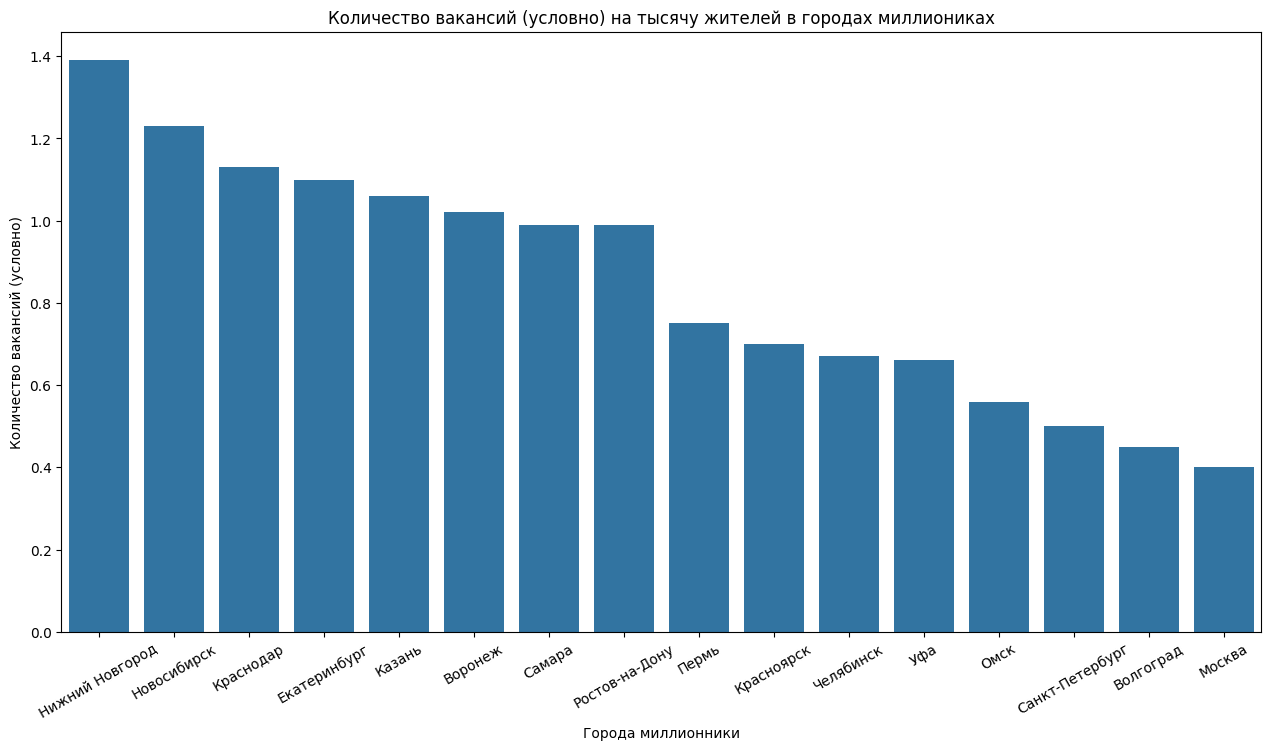

In [71]:
# Построение столбчатой диаграммы для
# отображения количества вакансий на тысячу жителей в городах миллиониках

barplot_data = df.copy()

fig = plt.figure(figsize=(12,6))
axes = fig.add_axes([0,0,1,1])

barplot = sns.barplot(
    data=barplot_data,
    x='city',    
    y='vacancies/population'    
)

barplot.set_xticklabels(labels=barplot.get_xticklabels(), rotation=30)
barplot.set_title('Количество вакансий (условно) на тысячу жителей в городах миллиониках')
barplot.set_ylabel('Количество вакансий (условно)')
barplot.set_xlabel('Города миллионники');

### Построние тепловой карты для анализа Распределения количества вакансий в зависимости от дипазонов заработной платы в городах миллионниках.

In [72]:
# запрос 
# текст запроса# текст запроса
query_7_2 = f''' 
WITH sal_cte AS
    (
    SELECT area_id , name, experience, 
        -- определяеи среднюю зарплату либо как среднюю от salary_from до salary_to
        -- или как одну из salary_from или salary_to если другая равна 0
        CASE 
            WHEN salary_from IS NOT NULL AND salary_to IS NOT NULL
            THEN
                ( salary_from + salary_to ) / 2.0
            WHEN salary_from IS NOT NULL OR salary_to IS NOT NULL
            THEN    
                coalesce(salary_from, 0) * 1.0 + coalesce(salary_to, 0) * 1.0
        END AS avg_salary

        FROM vacancies
        WHERE NOT (salary_from IS NULL AND salary_to IS NULL)
    )

    SELECT a.name as city, s.name, s.experience, s.avg_salary
    FROM sal_cte AS s
        JOIN areas as a On s.area_id = a.id 
    WHERE  a.name IN ({cities})

'''

In [73]:
# результат запроса
df = pd.read_sql_query(query_7_2, connection)
display(df)

,city,name,experience,avg_salary
0,Екатеринбург,Системный администратор,От 1 года до 3 лет,50000.0
1,Красноярск,Ночной Специалист службы технической поддержки,От 1 года до 3 лет,32500.0
2,Воронеж,Программист 1С,От 1 года до 3 лет,120000.0
3,Москва,QA engineer (Web),От 1 года до 3 лет,100000.0
4,Новосибирск,Разработчик видеоигр (Unity разработчик),От 1 года до 3 лет,150000.0
...,...,...,...,...
10529,Санкт-Петербург,Системный администратор,От 1 года до 3 лет,50000.0
10530,Екатеринбург,Backend-разработчик,От 1 года до 3 лет,115000.0
10531,Новосибирск,QA Automation Engineer,От 3 до 6 лет,275000.0
10532,Санкт-Петербург,Специалист сопровождения медицинской информаци...,Нет опыта,50000.0


In [74]:
# смотрим статистическую информацию по полученной средней зарплате
df['avg_salary'].describe()

count      10534.000000
mean       97980.367951
std        73089.344951
min           35.000000
25%        46000.000000
50%        75000.000000
75%       126061.500000
max      1000000.000000
Name: avg_salary, dtype: float64

In [75]:
# т.к есть странная мин. зарплата 35, 
# то проверяем зарплаты меньше 1 000
mask = df['avg_salary'] < 1_000
df[mask]

,city,name,experience,avg_salary
501,Воронеж,Инженер по информационной безопасности,Нет опыта,35.0
610,Самара,Системный администратор,От 3 до 6 лет,70.0
6088,Москва,Computer Vision Engineer,От 3 до 6 лет,300.0


Такие зарплаты для таких вакансий скорее всего ошибочны, поэтому в дальнейшем сделаем условие для зарплат более 1000 руб

In [76]:
# сделаем аналогичную проверку для высоких зарплат
mask = df['avg_salary'] > 500_000
df[mask]

,city,name,experience,avg_salary
336,Москва,Директор по информационным технологиям,От 3 до 6 лет,650000.0
540,Санкт-Петербург,Технический директор,Более 6 лет,1000000.0
2366,Пермь,Product manager LATOKEN,От 3 до 6 лет,600000.0
3888,Москва,"Директор IT (HoReCa, Retail)",Более 6 лет,550000.0
4685,Москва,СТО/Директор по разработке,От 3 до 6 лет,750000.0
5940,Москва,Руководитель команды разработки,От 3 до 6 лет,600000.0
6118,Москва,Project/Delivery manager,От 3 до 6 лет,546087.0
6959,Уфа,Product manager LATOKEN,От 3 до 6 лет,600000.0
7128,Москва,1С:Эксперт по производительности 1С,От 3 до 6 лет,650000.0
7707,Москва,Chief Product Officer (CPO),Более 6 лет,550000.0


Высокие зарплаты для таких вакансий имеют право быть, поэтому ограничение сверху накладвать не будем.

In [77]:
# накладываем ограничение снизу
df = df[df['avg_salary'] > 1_000].reset_index(drop=True)

Анализируем зарплаты для правильной группировки зарплат при построении тепловой карты.

In [79]:
# смотрим процентную статистику зарплат (для удобства умножил на 100)
df['avg_salary'].value_counts(normalize=True) * 100

avg_salary
100000.0    5.953851
50000.0     5.222676
60000.0     4.937803
40000.0     4.899820
80000.0     4.500997
              ...   
160920.0    0.009496
55763.5     0.009496
111500.0    0.009496
107552.5    0.009496
34547.0     0.009496
Name: proportion, Length: 656, dtype: float64

In [80]:
# отбираем зарплаты, которых  в выборке более 1%
df_sp = (df['avg_salary'].value_counts(normalize=True) * 100 > 1).to_frame().reset_index()
mask = df_sp['proportion'] == True
df_sp = df_sp[mask].reset_index(drop=True)

In [81]:
# смотрим зарплаты, которых  в выборке более 1% 
df_sp['avg_salary'].sort_values(ignore_index=True)

0      25000.0
1      30000.0
2      35000.0
3      40000.0
4      42500.0
5      45000.0
6      50000.0
7      55000.0
8      60000.0
9      65000.0
10     70000.0
11     75000.0
12     80000.0
13     85000.0
14     90000.0
15    100000.0
16    110000.0
17    120000.0
18    125000.0
19    130000.0
20    140000.0
21    150000.0
22    160000.0
23    200000.0
24    250000.0
Name: avg_salary, dtype: float64

In [82]:
# для построения тепловой карты достаточной будет 9 групп зарплат
# на основании указанных вышке данных создаём список таких групп
sal_group = df_sp['avg_salary'].sort_values(ignore_index=True).to_list()[::3]
sal_group = list( map(round , sal_group) )
display(sal_group)

[25000, 40000, 50000, 65000, 80000, 100000, 125000, 150000, 250000]

In [83]:
# Функция разделяющая зарплаты по группам
# для каждой цены, определяеи диапазон 
# из определённого выше списка sal_group
# для удобства дальнейшей сортировки тепловой карты,
# для каждой группы возвращаем её номер (по-сути индекс в списке)
def get_sal_group(salary, sal_group):
    len_sg = len(sal_group)
    for i, g in enumerate(sal_group):
        if salary <= g and i == 0:
            return (f"До {g}", i)
        elif salary <= g and i < (len_sg - 1):
            return (f"От {sal_group[i - 1]} до {g}", i)
        elif salary < g and i == (len_sg - 1):
            return (f"От {sal_group[i - 1]} до {g}", i)
        elif salary >= g and i == (len_sg - 1):
            return (f"Выше {g}" , i + 1)

In [84]:
# создаём копию полученного из запроса dataframe
heatmap_data = df.copy()
heatmap_data['Дипазон зарплаты'], heatmap_data['Номер дипазона зарплаты'] = \
    zip( * heatmap_data['avg_salary'].apply(get_sal_group, sal_group=sal_group) )
        
display(  pd.concat( (heatmap_data.head(3), heatmap_data.tail(3)) )  )

,city,name,experience,avg_salary,Дипазон зарплаты,Номер дипазона зарплаты
0,Екатеринбург,Системный администратор,От 1 года до 3 лет,50000.0,От 40000 до 50000,2
1,Красноярск,Ночной Специалист службы технической поддержки,От 1 года до 3 лет,32500.0,От 25000 до 40000,1
2,Воронеж,Программист 1С,От 1 года до 3 лет,120000.0,От 100000 до 125000,6
10528,Новосибирск,QA Automation Engineer,От 3 до 6 лет,275000.0,Выше 250000,9
10529,Санкт-Петербург,Специалист сопровождения медицинской информаци...,Нет опыта,50000.0,От 40000 до 50000,2
10530,Уфа,Технический писатель (Платформа СБИС),Нет опыта,59000.0,От 50000 до 65000,3


In [85]:
# проверка на незаполненные значения диапазона зарплат
mask = heatmap_data['Дипазон зарплаты'] != heatmap_data['Дипазон зарплаты']
heatmap_data[mask]

,city,name,experience,avg_salary,Дипазон зарплаты,Номер дипазона зарплаты


In [86]:
# Отсортировал для дальнейшего упорядочиванного отображения Диапазонов зарплаты на графике
heatmap_data = heatmap_data.sort_values(by = 'Номер дипазона зарплаты', ignore_index=True)
# создание списка Диапазонов зарплаты из упорядоченной таблицы (для уникальности удаляя дубликаты)
# для правильного отображения диапазонов на тепловой карте
salary_group = heatmap_data.drop_duplicates(['Номер дипазона зарплаты'])['Дипазон зарплаты'].to_list()
print(salary_group)

['До 25000', 'От 25000 до 40000', 'От 40000 до 50000', 'От 50000 до 65000', 'От 65000 до 80000', 'От 80000 до 100000', 'От 100000 до 125000', 'От 125000 до 150000', 'От 150000 до 250000', 'Выше 250000']


In [87]:
# для такого же отображения городов, как на столбчатой диаграмме
# используем определённый ранее список city_order
heatmap_data['city_number'] = heatmap_data['city'].map(lambda x : city_order.index(x) ).astype(int)

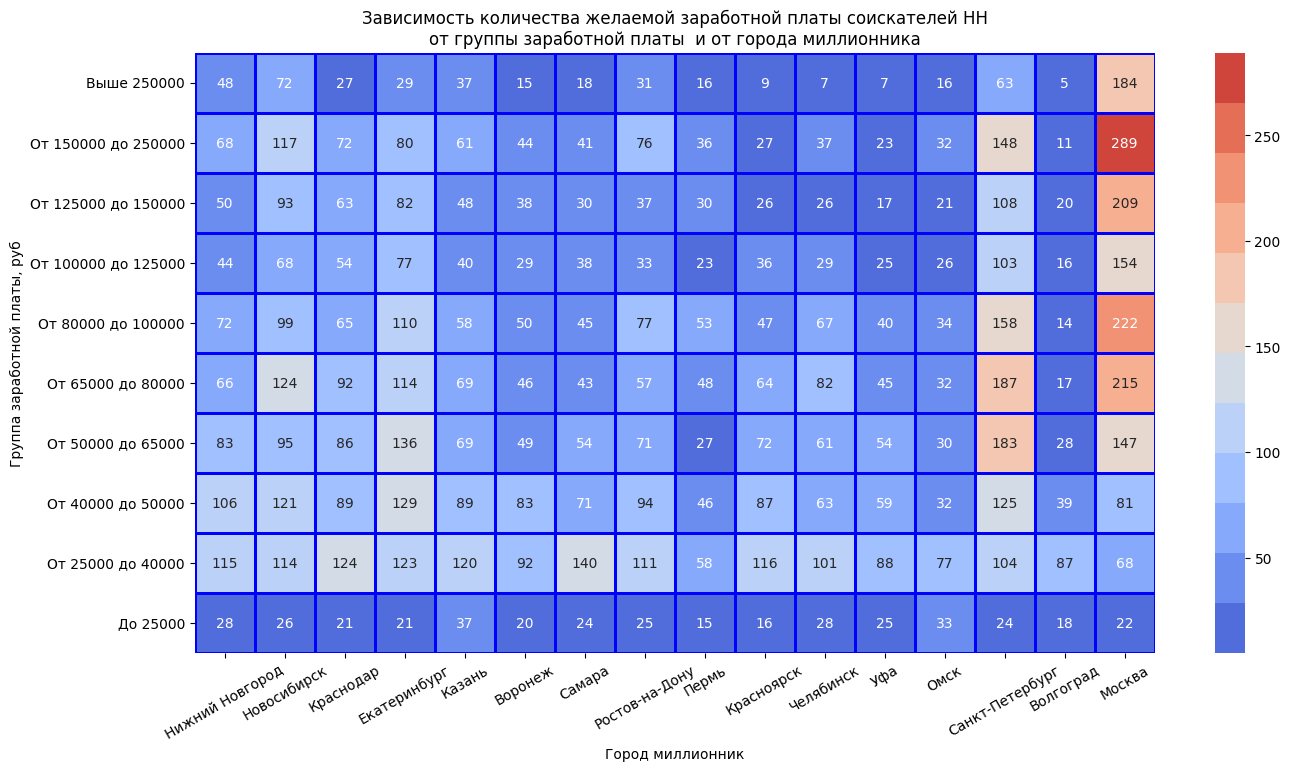

In [88]:
fig = plt.figure(figsize=(12,6))
axes = fig.add_axes([0,0,1,1])

hm_data = heatmap_data.pivot_table(
    values='avg_salary', 
    index=['Номер дипазона зарплаты'], 
    columns=['city_number'], 
    aggfunc=['count']
    )

colormap = sns.color_palette("coolwarm", 12)

hm = sns.heatmap(
    hm_data,
    linewidth=1,
    linecolor='b',
    cmap=colormap,
    annot=True,
    fmt='.0f' 
)

hm.invert_yaxis()
hm.invert_xaxis()
hm.set_ylabel('Группа заработной платы, руб')
hm.set_xlabel('Город миллионник')
hm.set_xticklabels(city_order, rotation=30) # для такого же отображения городов, как для отображения столбчатой диаграммы
hm.set_yticklabels(salary_group, rotation=0) # для отображения диапазонов
hm.set_title('Зависимость количества желаемой заработной платы соискателей HH'+'\n'+'от группы заработной платы  и от города миллионника');

Выводы:  
Ожидаемо самое большое количество высокооплачиванмых вакансий в Мсокве и Санкт-Петербурге.  
Но, интересно, как изменятся показатели если взять эти данные относительно населения городов-миллионников.

### Построние тепловой карты для анализа Распределения количества вакансий в зависимости от дипазонов заработной платы относительно численности населения в городах миллионниках.

In [89]:
# добавляем дметодом слияний данные о начелении городов-милллионниках
heatmap_data= heatmap_data.merge(
    df_city_popul,
    on = 'city'    
    )
# преобразуем данные о численности населения к числовому типу
heatmap_data['population'] = heatmap_data['population'].astype("float32")

In [90]:
# группируем данные с подсчётом количества зарплаты
# в той или иной группе зарплаты, номера города-миллионика, численности населения
hm_new_data = heatmap_data.groupby(
    by=['Номер дипазона зарплаты', 'city_number', 'population'], 
    as_index=False
    )[['avg_salary']].count()

hm_new_data['avg_salary_proportion'] = hm_new_data['avg_salary'] / hm_new_data['population']

In [91]:
# необходимости нет, но для сделал для понимания правильного соответствия 
# между 'Номер дипазона зарплаты' и списком salary_group
# и между 'city_number' и списком city_order
hm_new_data = hm_new_data.sort_values(by=['Номер дипазона зарплаты', 'city_number'])
display(hm_new_data.head(20))

,Номер дипазона зарплаты,city_number,population,avg_salary,avg_salary_proportion
0,0,0,13274.0,22,0.001657
1,0,1,1012.0,18,0.017787
2,0,2,5653.0,24,0.004246
3,0,3,1101.0,33,0.029973
4,0,4,1166.0,25,0.021441
5,0,5,1177.0,28,0.023789
6,0,6,1212.0,16,0.013201
7,0,7,1028.0,15,0.014591
8,0,8,1143.0,25,0.021872
9,0,9,1154.0,24,0.020797


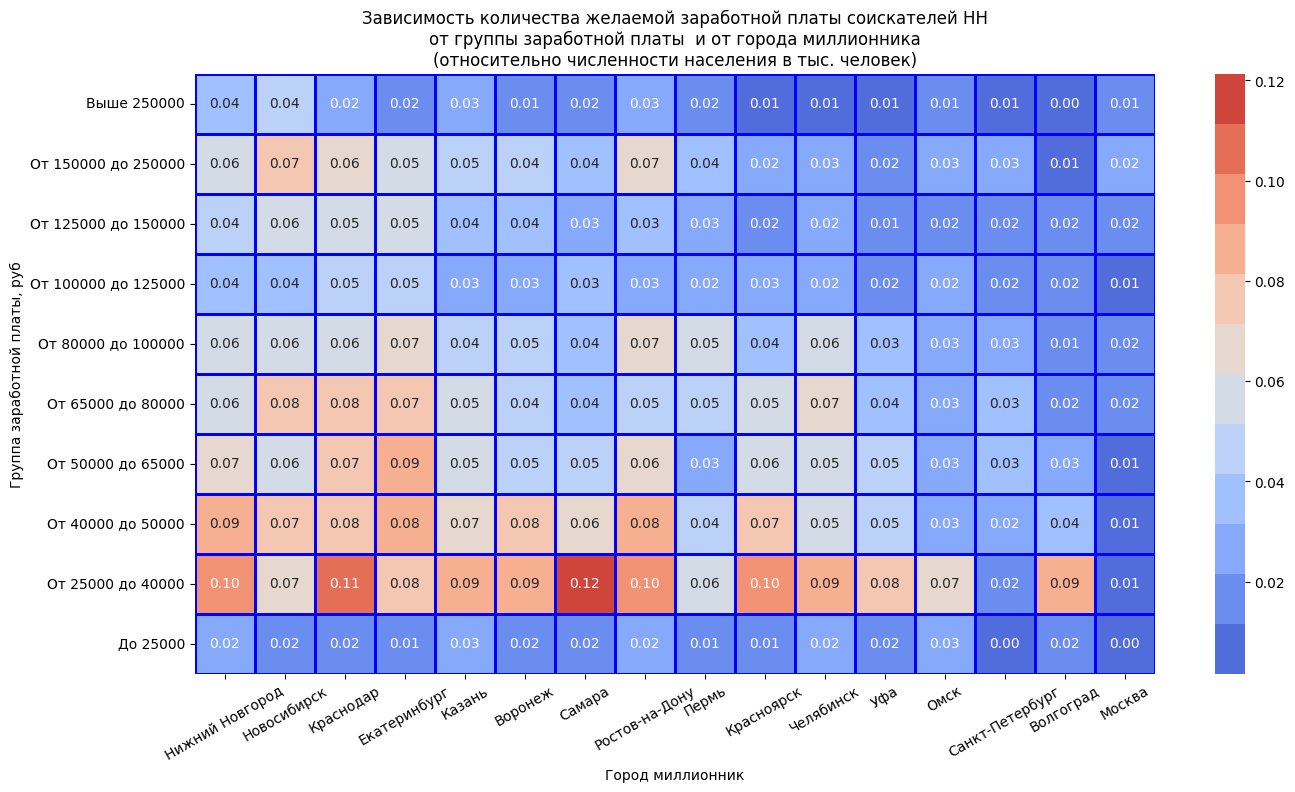

In [92]:
# построение тепловой карты
fig = plt.figure(figsize=(12,6))
axes = fig.add_axes([0,0,1,1])

hm_data = hm_new_data.pivot_table(
    values='avg_salary_proportion', 
    index=['Номер дипазона зарплаты'], 
    columns=['city_number']   
    )

colormap = sns.color_palette("coolwarm", 12)

hm = sns.heatmap(
    hm_data,
    linewidth=1,
    linecolor='b',
    cmap=colormap,
    annot=True,
    fmt='.2f' 
)

hm.invert_yaxis()
hm.invert_xaxis()
hm.set_ylabel('Группа заработной платы, руб')
hm.set_xlabel('Город миллионник')
hm.set_xticklabels(city_order, rotation=30) # для такого же отображения городов, как для отображения столбчатой диаграммы
hm.set_yticklabels(salary_group, rotation=0) # для отображения диапазонов
hm.set_title(
    'Зависимость количества желаемой заработной платы соискателей HH'+\
        '\n' + 'от группы заработной платы  и от города миллионника'+\
        '\n' + '(относительно численности населения в тыс. человек)'   
    );

Выводы:  
Видно, что при таком анализе у Москвы и Санкт-Петербурга гораздо более скромные показатели, чем у других городов.  
Здесь уже не лидируют Москва и Санкт-Петербург.  
Скорее всего это признак динамичного развитии экономики в других городах-миллионниках.  
Особенно выделяются: Нижний Новгород, Новосибирск, Краснодар, Екатеринбург, Ростов-на-Дону.

<a id="1"></a> <br>
### Дополнительные запросы

<a id="3"></a> <br>
#### Запрос 7_3

In [93]:
# Запрос для определения количества вакансий работодателей, 
# у которых в качестве сферы деятельности указана Разработка программного обеспечения
query_7_3 = f'''
    Select e.name, Count(v.id)
        From vacancies as v
            Join employers as e On v.employer_id = e.id
                Join employers_industries as ei On e.id = ei.employer_id
                    Join industries as i On ei.industry_id = i.id 
    Where i.name = 'Разработка программного обеспечения'
    Group by e.name
    Order by Count(v.id) Desc
'''

In [94]:
# результат запроса
df = pd.read_sql_query(query_7_3, connection)
display(df)

,name,count
0,Тинькофф,444
1,DataArt,247
2,Совкомбанк Технологии,204
3,IBS,175
4,Тензор,155
...,...,...
2579,Индустрия делового программного обеспечения,1
2580,"Айтекс, Центр Информационных Технологий",1
2581,Айтек,1
2582,"ИНКОМ, группа компаний",1


<a id="5"></a> <br>
#### Запрос 7_5

In [95]:
# текст запроса для определения количества вакансий дата-сайентистов
# просто ранее потроенный запрос 6_2, но без выделения junior
query_7_5 = f'''
    Select Count(id)
        From vacancies
    Where 
            (
                    lower(name) Like '%data scientist%'
                Or
                    lower(name) Like '%data science%'
                Or
                    lower(name) Like '%исследователь данных%'
                Or
                    lower(name) Like '%machine learning%'
                Or
                    lower(name) Like '%машинн%обучен%'
                Or
                    (
                            name Like '%ML%'
                        And
                            name Not Like '%HTML%'            
                    )    
            )
'''

In [96]:
# результат запроса
df = pd.read_sql_query(query_7_5, connection)
display(df)

,count
0,480


In [97]:
# не забываем закрыть соединение после окончания работы
connection.close()